In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings('ignore')

PASTA = "/content/drive/MyDrive/CFEM Minas Gerais"

os.makedirs(f"{PASTA}/graficos",          exist_ok=True)
os.makedirs(f"{PASTA}/dados_processados", exist_ok=True)

print(f"✅ Drive montado. Pasta de trabalho:")
print(f"   {PASTA}")
print(f"   Arquivos disponíveis: {os.listdir(PASTA)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive montado. Pasta de trabalho:
   /content/drive/MyDrive/CFEM Minas Gerais
   Arquivos disponíveis: ['CFEM_Arrecadacao_2022_2026.csv', 'CFEM_Arrecadacao_2017_2021.xlsx', 'Untitled0.ipynb', 'graficos', 'dados_processados']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

df_mg = pd.read_csv(f"{PASTA}/dados_processados/cfem_mg_limpo.csv")
df_mg['Data'] = pd.to_datetime(
    df_mg['Ano'].astype(str) + '-' + df_mg['Mês'].astype(str).str.zfill(2) + '-01'
)

ROMPIMENTO = pd.Timestamp('2019-01-25')
print(f"Registros de Brumadinho: {len(df_mg[df_mg['Município']=='BRUMADINHO']):,}")
print(f"Data do rompimento: {ROMPIMENTO.date()}")


Registros de Brumadinho: 2,555
Data do rompimento: 2019-01-25


In [ ]:
brum = (df_mg[df_mg['Município'] == 'BRUMADINHO']
        .groupby('Data')['ValorRecolhido'].sum().reset_index())
brum.columns = ['Data','CFEM']
brum['Fase'] = brum['Data'].apply(
    lambda d: 'Pré-rompimento' if d < ROMPIMENTO else 'Pós-rompimento'
)

media_pre = brum[brum['Fase']=='Pré-rompimento']['CFEM'].mean()
media_pos = brum[brum['Fase']=='Pós-rompimento']['CFEM'].mean()

print(f"Média mensal pré-rompimento : R$ {media_pre/1e6:.2f} milhões")
print(f"Média mensal pós-rompimento : R$ {media_pos/1e6:.2f} milhões")
print(f"Queda na média mensal       : {(media_pos-media_pre)/media_pre*100:.1f}%")


Média mensal pré-rompimento : R$ 4.14 milhões
Média mensal pós-rompimento : R$ 8.32 milhões
Queda na média mensal       : 101.2%


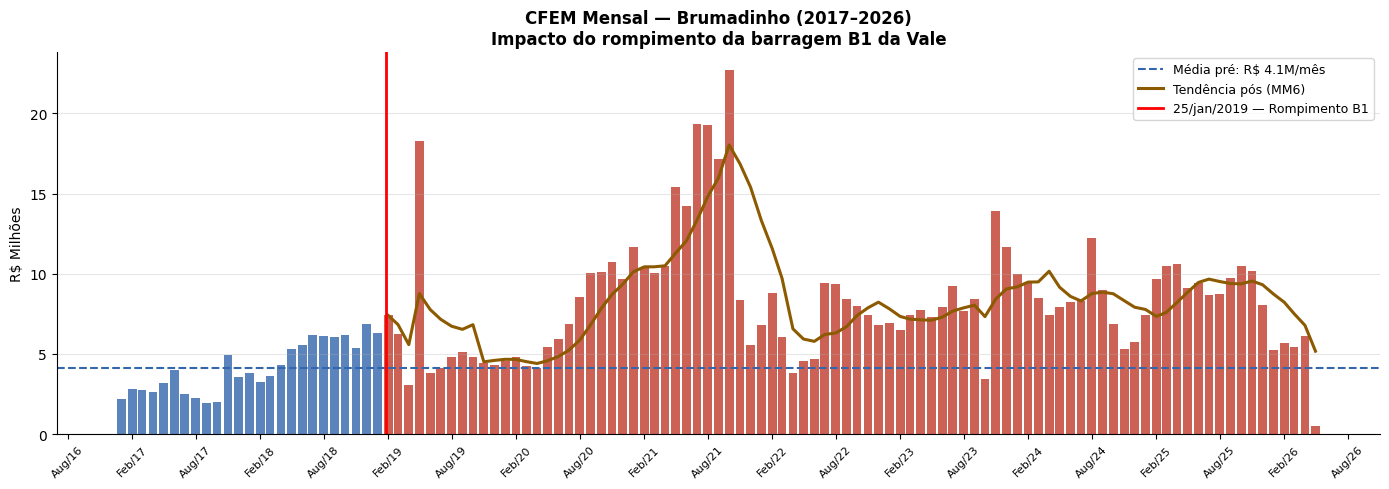

Gráfico salvo no Drive ✅


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

cores_b = ['#3266ad' if d < ROMPIMENTO else '#C0392B' for d in brum['Data']]
ax.bar(brum['Data'], brum['CFEM']/1e6, width=25, color=cores_b, alpha=0.8)

ax.axhline(media_pre/1e6, color='#3266ad', linestyle='--', linewidth=1.5,
           label=f'Média pré: R$ {media_pre/1e6:.1f}M/mês')

mm6 = brum[brum['Fase']=='Pós-rompimento']['CFEM'].rolling(6, min_periods=1).mean()
ax.plot(brum[brum['Fase']=='Pós-rompimento']['Data'], mm6/1e6,
        color='#8C5A00', linewidth=2.2, label='Tendência pós (MM6)')

ax.axvline(ROMPIMENTO, color='red', linewidth=2, label='25/jan/2019 — Rompimento B1')

ax.set_title('CFEM Mensal — Brumadinho (2017–2026)\nImpacto do rompimento da barragem B1 da Vale',
             fontsize=12, fontweight='bold')
ax.set_ylabel('R$ Milhões', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, fontsize=8)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb4_brumadinho_serie.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


In [ ]:
brum_pos = brum[brum['Data'] >= ROMPIMENTO].copy()
brum_pos['Esperado'] = media_pre
brum_pos['Perda']    = (brum_pos['Esperado'] - brum_pos['CFEM']).clip(lower=0)

perda_total       = brum_pos['Perda'].sum()
meses_impactados  = (brum_pos['Perda'] > 0).sum()

print(f"Meses analisados pós-rompimento         : {len(brum_pos)}")
print(f"Meses abaixo da média histórica pré     : {meses_impactados}")
print(f"Perda estimada de CFEM (vs média pré)   : R$ {perda_total/1e6:.1f} milhões")
print(f"Equivale a                               : R$ {perda_total/1e9:.3f} bilhões")
print()
print("⚠️  Limite inferior — não considera a alta dos preços do minério")
print("    que elevaria a base de comparação no período pós-2020.")


Meses analisados pós-rompimento         : 88
Meses abaixo da média histórica pré     : 7
Perda estimada de CFEM (vs média pré)   : R$ 6.1 milhões
Equivale a                               : R$ 0.006 bilhões

⚠️  Limite inferior — não considera a alta dos preços do minério
    que elevaria a base de comparação no período pós-2020.


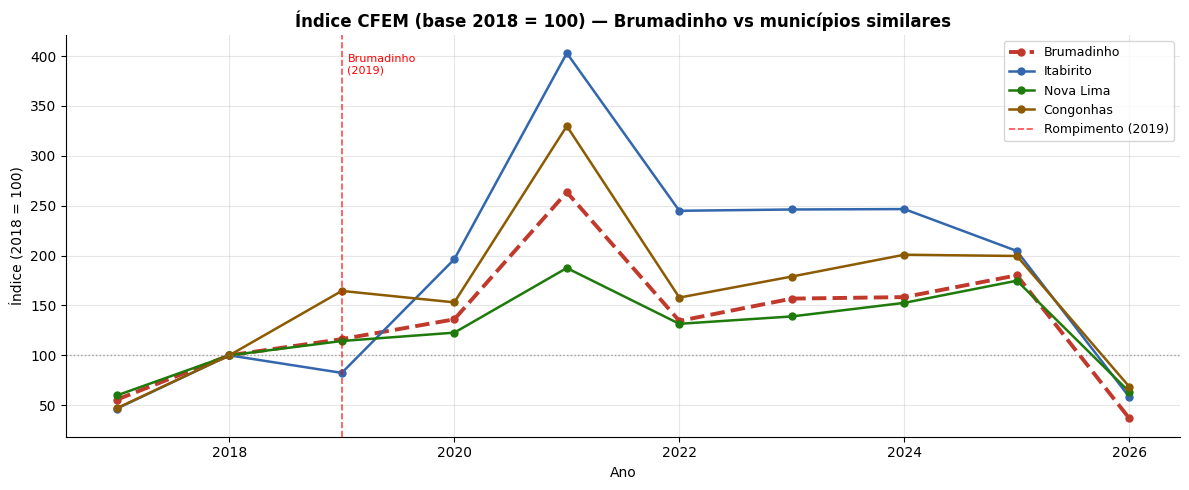

Gráfico salvo no Drive ✅


In [ ]:
comparados = ['BRUMADINHO','ITABIRITO','NOVA LIMA','CONGONHAS']

pivot = (df_mg[df_mg['Município'].isin(comparados)]
         .groupby(['Ano','Município'])['ValorRecolhido'].sum()
         .unstack('Município').fillna(0) / 1e6)

base = pivot.loc[2018]
pivot_idx = pivot.div(base) * 100

fig, ax = plt.subplots(figsize=(12, 5))
estilos = {'BRUMADINHO': ('--', 2.8, '#C0392B'),
            'ITABIRITO':  ('-',  1.8, '#3266ad'),
            'NOVA LIMA':  ('-',  1.8, '#1E7A0A'),
            'CONGONHAS':  ('-',  1.8, '#8C5A00')}

for mun in comparados:
    if mun in pivot_idx.columns:
        ls, lw, cor = estilos[mun]
        ax.plot(pivot_idx.index, pivot_idx[mun], marker='o', markersize=5,
                linestyle=ls, linewidth=lw, color=cor, label=mun.title())

ax.axhline(100, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(2019, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Rompimento (2019)')
ax.text(2019.05, pivot_idx.values.max()*0.95, 'Brumadinho\n(2019)',
        color='red', fontsize=8)

ax.set_title('Índice CFEM (base 2018 = 100) — Brumadinho vs municípios similares',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Índice (2018 = 100)', fontsize=10)
ax.set_xlabel('Ano', fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb4_brumadinho_indexado.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


Top 8 substâncias — Brumadinho (R$ Milhões):
Fase              Pré-rompimento  Pós-rompimento       Total
Substância                                                  
FERRO                  40.527225      619.984995  660.512220
MINÉRIO DE FERRO       61.097933      109.507734  170.605667
HEMATITA                1.530627        0.278703    1.809329
GRANITO                 0.054966        1.395969    1.450935
ÁGUA MINERAL            0.186116        1.165127    1.351243
AREIA                   0.060668        0.205734    0.266402
ARGILA                  0.000000        0.000049    0.000049

Pré-rompimento: R$ 103.5M total | dominante: MINÉRIO DE FERRO (59.1%)

Pós-rompimento: R$ 732.5M total | dominante: FERRO (84.6%)


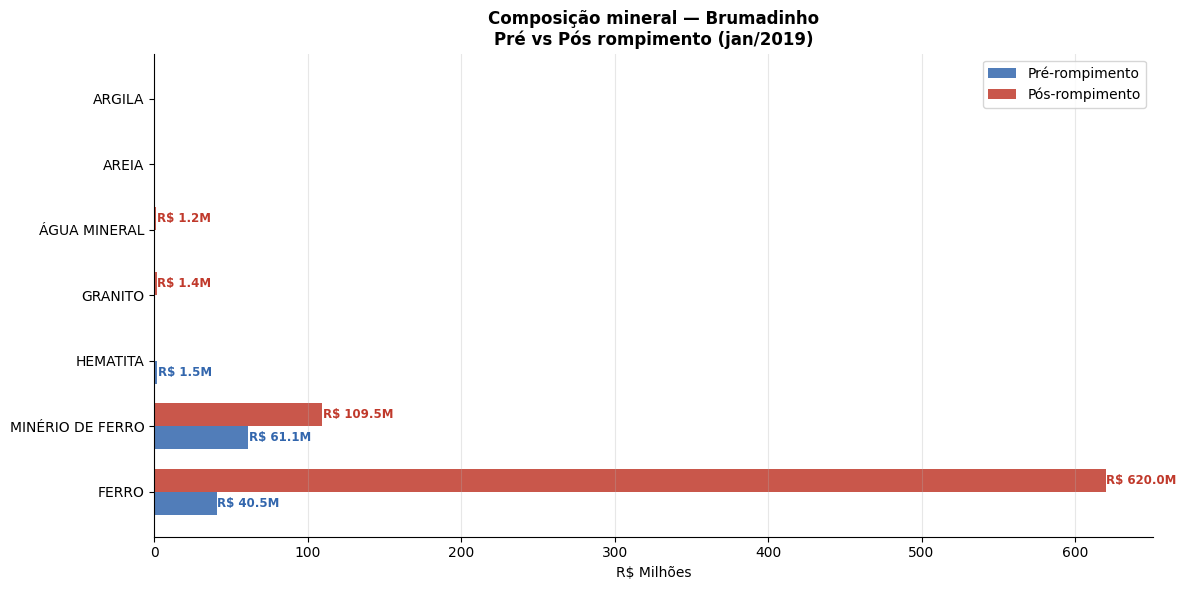

Gráfico salvo no Drive ✅


In [ ]:
brum_df  = df_mg[df_mg['Município']=='BRUMADINHO'].copy()
ROMPIMENTO = pd.Timestamp('2019-01-25')
brum_df['Data'] = pd.to_datetime(
    brum_df['Ano'].astype(str) + '-' + brum_df['Mês'].astype(str).str.zfill(2) + '-01'
)
brum_df['Fase'] = brum_df['Data'].apply(
    lambda d: 'Pré-rompimento' if d < ROMPIMENTO else 'Pós-rompimento'
)

brum_sub = (brum_df.groupby(['Substância','Fase'])['ValorRecolhido']
            .sum().unstack('Fase').fillna(0) / 1e6)
brum_sub['Total'] = brum_sub.sum(axis=1)
brum_sub = brum_sub.sort_values('Total', ascending=False).head(8)

print("Top 8 substâncias — Brumadinho (R$ Milhões):")
print(brum_sub.to_string())

for fase in brum_sub.columns[:-1]:
    tot  = brum_sub[fase].sum()
    top1 = brum_sub[fase].idxmax()
    if tot > 0:
        print(f"\n{fase}: R$ {tot:.1f}M total | dominante: {top1} ({brum_sub.loc[top1,fase]/tot*100:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 6))

subst   = brum_sub.index.tolist()
x       = np.arange(len(subst))
w       = 0.35
cols    = [c for c in brum_sub.columns if c != 'Total']

cores   = {'Pré-rompimento': '#3266ad', 'Pós-rompimento': '#C0392B'}

for i, fase in enumerate(cols):
    vals = brum_sub[fase].values
    bars = ax.barh(x + (i - 0.5) * w, vals, height=w,
                   color=cores[fase], alpha=0.85, label=fase)
    for bar, val in zip(bars, vals):
        if val > 1:
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'R$ {val:.1f}M', va='center', fontsize=8.5, fontweight='bold',
                    color=cores[fase])

ax.set_yticks(x)
ax.set_yticklabels(subst, fontsize=10)
ax.set_xlabel('R$ Milhões', fontsize=10)
ax.set_title('Composição mineral — Brumadinho\nPré vs Pós rompimento (jan/2019)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb4_brumadinho_substancias.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")